# 📊 EDA — Alza Review Sentiment Dataset
Czech product reviews
**Label:** `1` = positive, `0` = negative

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 130

CSV_PATH = './get_data/batch_of_reviews.csv'   # adjust if running from a different cwd
df = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df):,} rows — columns: {list(df.columns)}')
df.head()

Loaded 37,705 rows — columns: ['text', 'label']


,text,label
0,lehké ovladani,1
1,realisticke,1
2,grafika krasna,1
3,lehce se prehreje konzole protoze edice 24 nen...,0
4,rychlé a intuitivní nastavení,1


In [2]:
dupes = df[df.duplicated(subset='text', keep=False)].sort_values('text')
print(f'Exact duplicate texts: {len(dupes)}')
print(f'Unique duplicated texts: {dupes["text"].nunique()}')
print()
print(dupes[['text','label']].head(20).to_string(index=False))

# drop exact duplicates
df = df.drop_duplicates(subset='text')

# drop reviews that are just noise (under 3 chars or only symbols)
df = df[df['text'].str.len() >= 5]
df = df[df['text'].str.match(r'.*[a-záčďéěíňóřšťúůýžäôľščťžý].*')]  # must contain at least one letter

print(df.shape)
print(df['label'].value_counts())

Exact duplicate texts: 28565
Unique duplicated texts: 4825

                                                                     text  label
                                     "mini", no vacsiu by som ani nechcel      1
                                     "mini", no vacsiu by som ani nechcel      1
                                         "povinné" rozšírenie kariet Bang      1
                                         "povinné" rozšírenie kariet Bang      1
"vůně" jako kombinace starého tuhého mýdla a spreje na záchod s vůní lesa      0
"vůně" jako kombinace starého tuhého mýdla a spreje na záchod s vůní lesa      0
                                                                       (:      1
                                                                       (:      1
                                              (na tomto nelze nic zkazit)      1
                                              (na tomto nelze nic zkazit)      1
                                                 

---
## 1. Basic Info

In [3]:
print('Shape:', df.shape)
print()
print('Dtypes:')
print(df.dtypes)
print()
print('Null values:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate texts:', df['text'].duplicated().sum())
df = df.dropna(subset=['text'])

Shape: (13759, 2)

Dtypes:
text       str
label    int64
dtype: object

Null values:
text     0
label    0
dtype: int64

Duplicate rows: 0
Duplicate texts: 0


---
## 2 · Class Distribution

              count  pct (%)
Negative (0)   3696     26.9
Positive (1)  10063     73.1


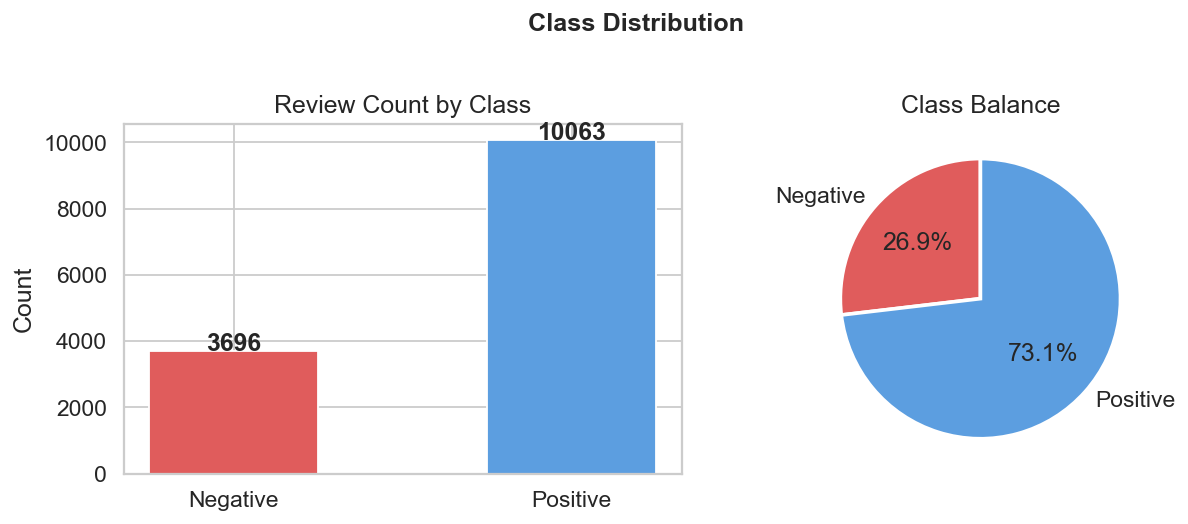


Imbalance ratio (pos:neg) = 2.72:1


In [4]:
counts = df['label'].value_counts().sort_index()
pct    = df['label'].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({'count': counts, 'pct (%)': pct.round(1)})
summary.index = ['Negative (0)', 'Positive (1)']
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# bar
colors = ['#e05c5c', '#5c9ee0']
axes[0].bar(['Negative', 'Positive'], counts.values, color=colors, edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[0].set_title('Review Count by Class')
axes[0].set_ylabel('Count')

# pie
axes[1].pie(counts.values, labels=['Negative', 'Positive'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Balance')

plt.suptitle('Class Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f'\nImbalance ratio (pos:neg) = {counts[1]/counts[0]:.2f}:1')

---
## 3 · Text Length Analysis

In [5]:
df['char_len']  = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print('=== Character length ===')
print(df.groupby('label')[['char_len']].describe().round(1))
print()
print('=== Word count ===')
print(df.groupby('label')[['word_count']].describe().round(1))

=== Character length ===
      char_len                                          
         count  mean   std  min   25%   50%   75%    max
label                                                   
0       3696.0  51.0  50.9  5.0  20.0  35.0  64.0  575.0
1      10063.0  32.9  32.0  5.0  15.0  23.0  39.0  588.0

=== Word count ===
      word_count                                     
           count mean  std  min  25%  50%   75%   max
label                                                
0         3696.0  8.6  8.6  1.0  3.0  6.0  11.0  81.0
1        10063.0  5.3  5.3  1.0  2.0  4.0   6.0  92.0


### Average negative review is 29.9 chars / 5.2 words — slightly longer than positive

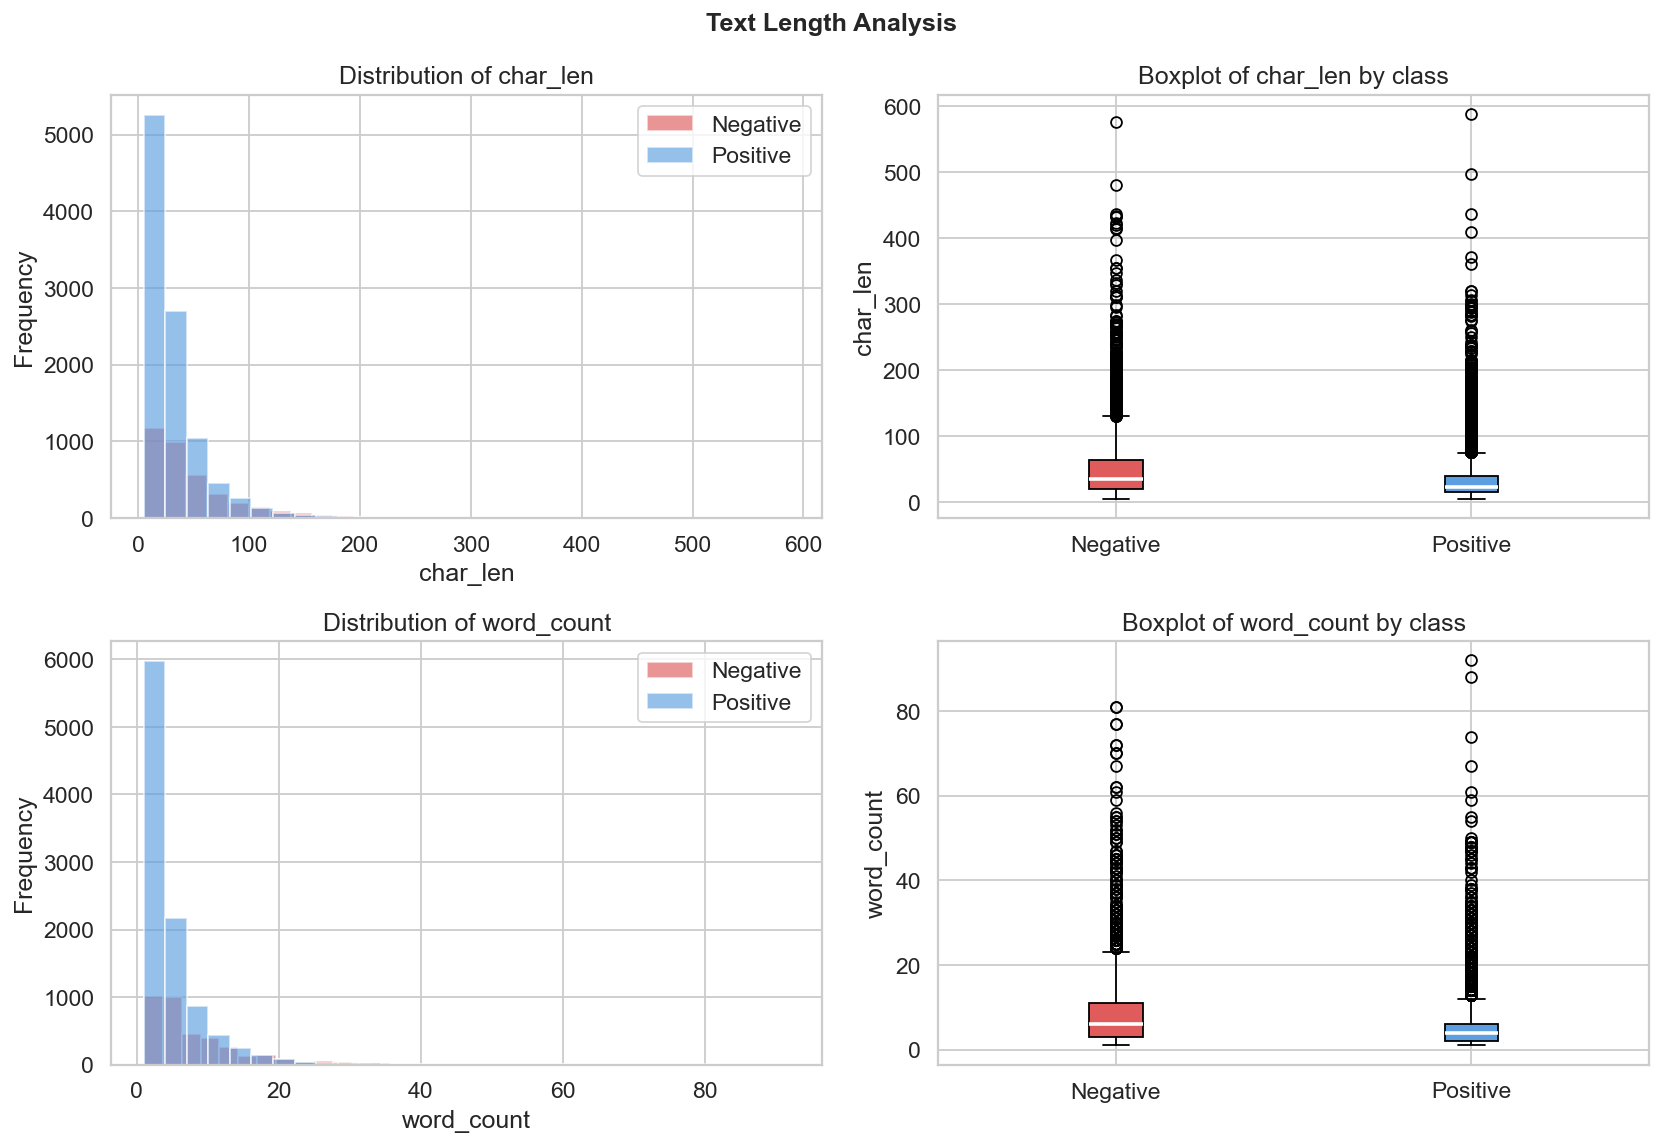

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
label_map  = {0: 'Negative', 1: 'Positive'}
pal = {0: '#e05c5c', 1: '#5c9ee0'}

for col, row_axes in zip(['char_len', 'word_count'], axes):
    # histogram
    for lbl, grp in df.groupby('label'):
        row_axes[0].hist(grp[col], bins=30, alpha=0.65,
                         label=label_map[lbl], color=pal[lbl], edgecolor='white')
    row_axes[0].set_title(f'Distribution of {col}')
    row_axes[0].set_xlabel(col)
    row_axes[0].set_ylabel('Frequency')
    row_axes[0].legend()

    # box
    data_box = [df[df['label']==0][col].values, df[df['label']==1][col].values]
    bp = row_axes[1].boxplot(data_box, patch_artist=True,
                              labels=['Negative', 'Positive'],
                              medianprops=dict(color='white', linewidth=2))
    for patch, c in zip(bp['boxes'], ['#e05c5c', '#5c9ee0']):
        patch.set_facecolor(c)
    row_axes[1].set_title(f'Boxplot of {col} by class')
    row_axes[1].set_ylabel(col)

plt.suptitle('Text Length Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4 · Top Words per Class

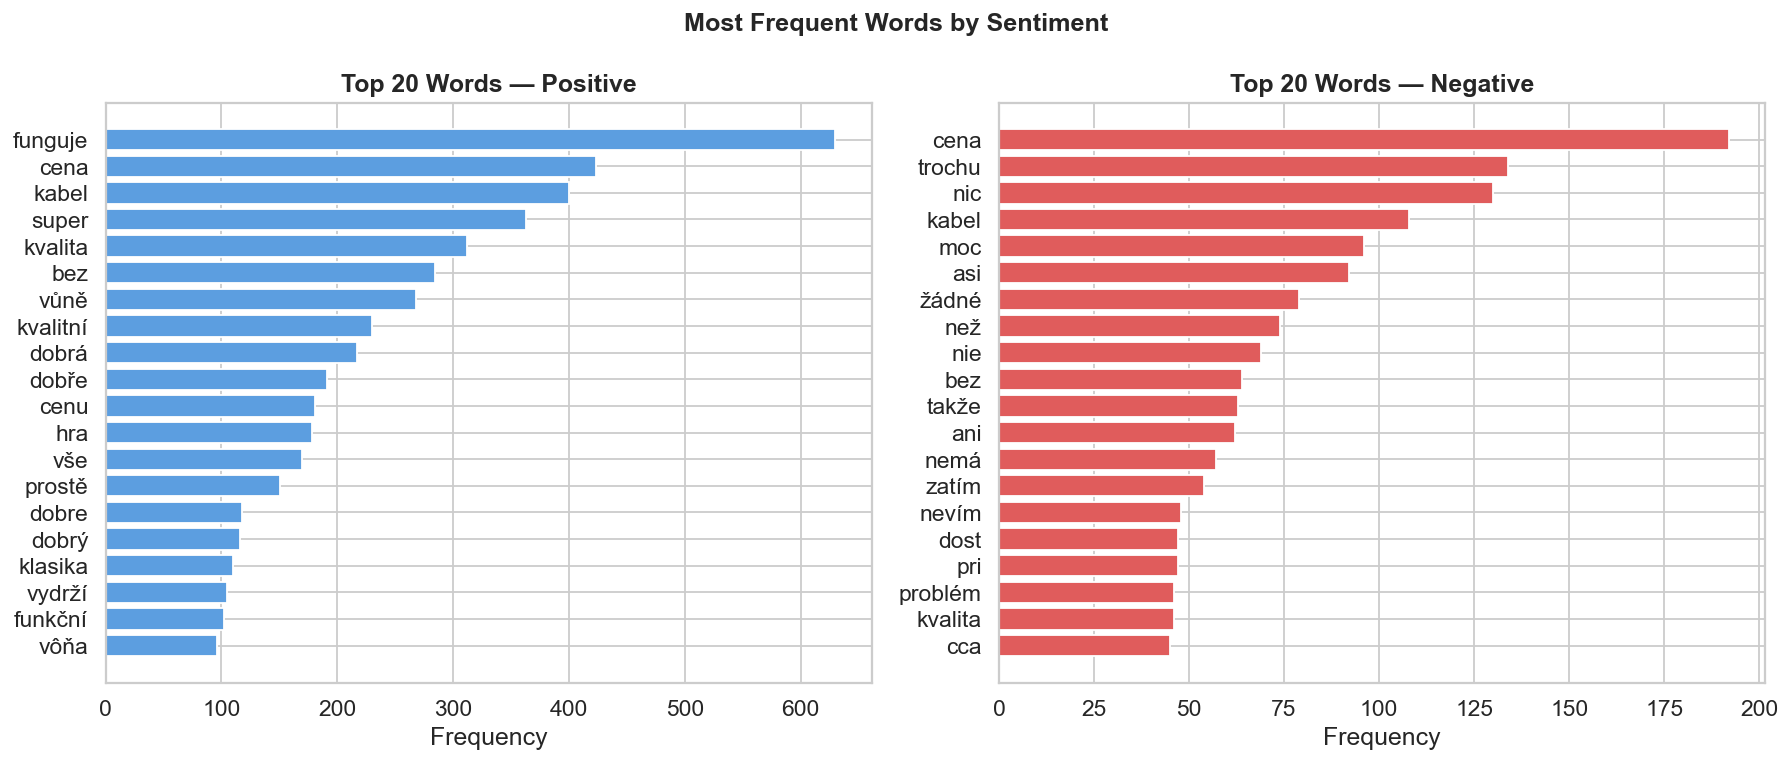

In [13]:
# Czech / Slovak stopwords (minimal set)
STOPWORDS = set([
    'a','i','v','na','je','se','to','že','jak','pro','ale','s','z','do',
    'jsem','jsou','byl','být','by','si','ve','po','jako','tak','jen','více',
    'k','o','u','co','za','není','má','ten','ta','to','při','mi','ho',
    'které','který','která','je','ze','nebo','také','jejich','když','tento',
    'tato','toto','velmi','bych','ne','ano','mě','mu','jej', 'som', 'ako'
])

def top_words(texts, n=20):
    words = []
    for t in texts:
        tokens = re.findall(r'[a-záčďéěíňóřšťúůýžäôľščťžýáéíóú]+', t.lower())
        words += [w for w in tokens if w not in STOPWORDS and len(w) > 2]
    return Counter(words).most_common(n)

top_pos = top_words(df[df['label']==1]['text'])
top_neg = top_words(df[df['label']==0]['text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, top, title, color in [
    (axes[0], top_pos, 'Top 20 Words — Positive', '#5c9ee0'),
    (axes[1], top_neg, 'Top 20 Words — Negative', '#e05c5c')
]:
    words, freqs = zip(*top)
    y = range(len(words))
    ax.barh(y, freqs, color=color, edgecolor='white')
    ax.set_yticks(y)
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words by Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 'cena' is ambigious word since it's present in both classes. 
Drop it

In [8]:
print(f'Before drop: {len(df)} rows')
df = df[df['text'].str.strip().str.lower() != 'cena']
print(f'Remaining rows: {len(df)}')

Before drop: 13759 rows
Remaining rows: 13759


---
## 6 · Character N-gram Analysis


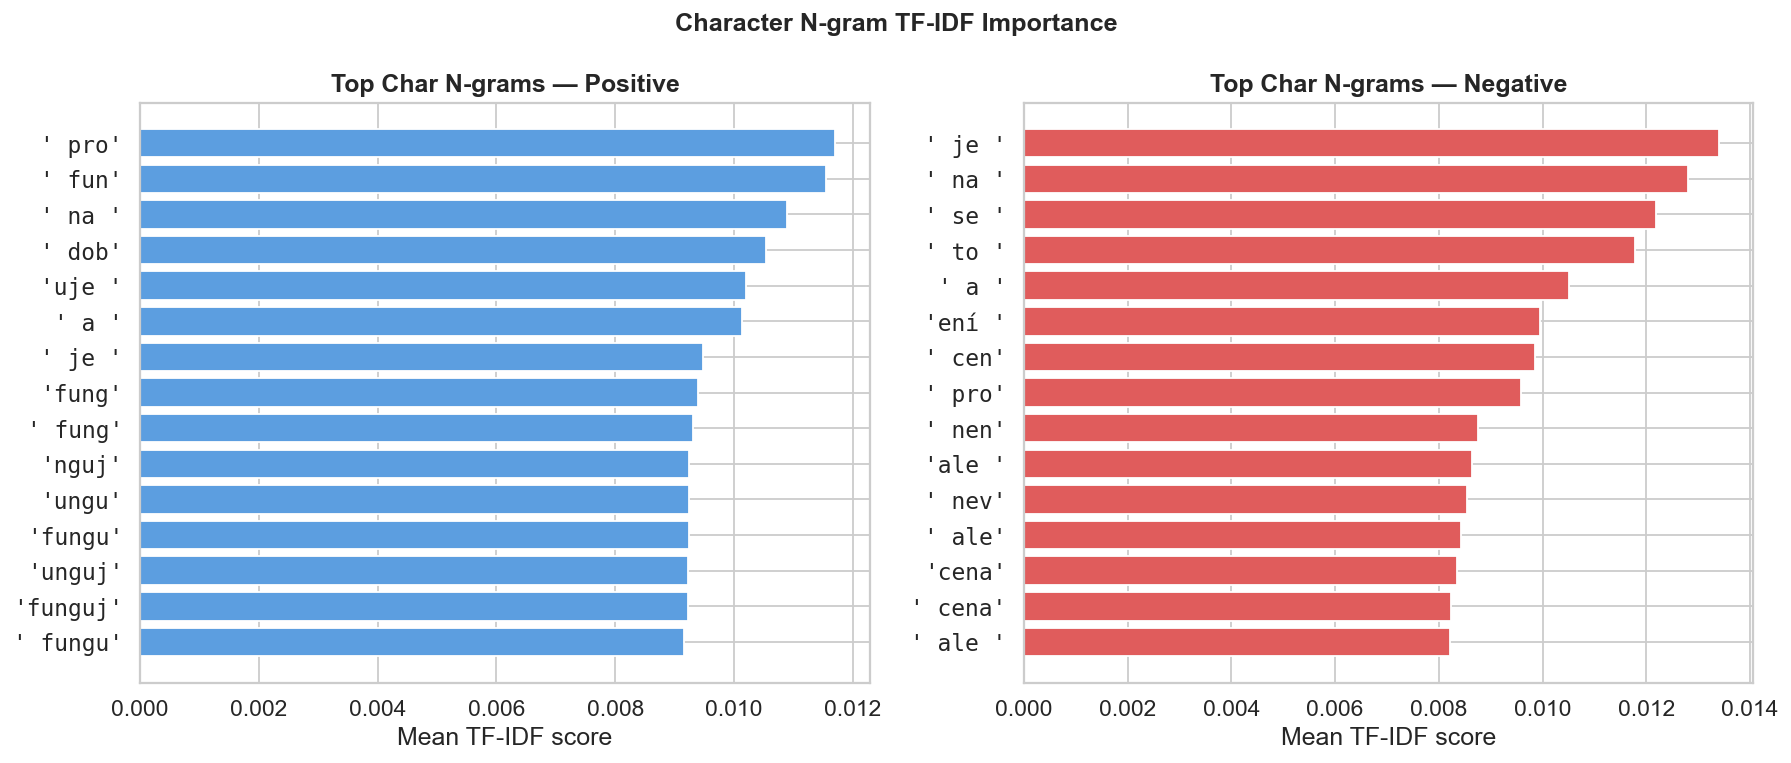

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

def top_ngrams_tfidf(texts, ngram_range=(4,6), n=15):
    vec = TfidfVectorizer(analyzer='char_wb', ngram_range=ngram_range,
                          max_features=5000, min_df=2, sublinear_tf=True)
    X = vec.fit_transform(texts)
    scores = np.asarray(X.mean(axis=0)).ravel()
    top_idx = scores.argsort()[-n:][::-1]
    vocab = vec.get_feature_names_out()
    return [(vocab[i], scores[i]) for i in top_idx]

pos_ngrams = top_ngrams_tfidf(df[df['label']==1]['text'].tolist())
neg_ngrams = top_ngrams_tfidf(df[df['label']==0]['text'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, ngrams, title, color in [
    (axes[0], pos_ngrams, 'Top Char N-grams — Positive', '#5c9ee0'),
    (axes[1], neg_ngrams, 'Top Char N-grams — Negative', '#e05c5c')
]:
    labels, scores = zip(*ngrams)
    y = range(len(labels))
    ax.barh(y, scores, color=color, edgecolor='white')
    ax.set_yticks(y)
    ax.set_yticklabels([repr(l) for l in labels], fontfamily='monospace')
    ax.invert_yaxis()
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Mean TF-IDF score')

plt.suptitle('Character N-gram TF-IDF Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7 Review Length vs. Sentiment (scatter)

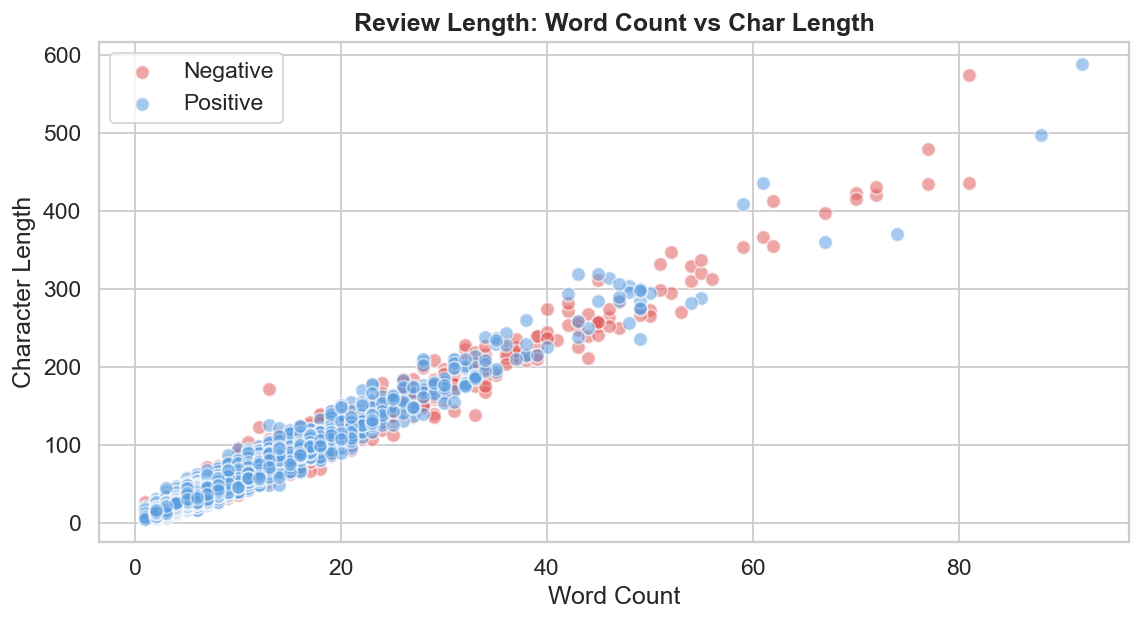

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

for lbl, name, color in [(0, 'Negative', '#e05c5c'), (1, 'Positive', '#5c9ee0')]:
    sub = df[df['label']==lbl]
    ax.scatter(sub['word_count'], sub['char_len'],
               alpha=0.55, label=name, color=color, edgecolors='white', s=60)

ax.set_xlabel('Word Count')
ax.set_ylabel('Character Length')
ax.set_title('Review Length: Word Count vs Char Length', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8 · Short Review Inspection
Very short reviews are often ambiguous or noisy — worth seeing what's in there.

In [11]:
threshold = 15   # characters
short = df[df['char_len'] <= threshold].copy()
short['sentiment'] = short['label'].map({0: 'Negative', 1: 'Positive'})

print(f'Reviews with ≤{threshold} characters: {len(short)}')
print()
print(short[['text', 'sentiment', 'char_len']].sort_values('char_len').to_string(index=False))

Reviews with ≤15 characters: 3297

           text sentiment  char_len
          Cena?  Negative         5
          Nič 🙂  Negative         5
          4,7Gb  Positive         5
          Zadne  Positive         5
          Vonia  Positive         5
          vidrž  Negative         5
          Výšky  Positive         5
          hezký  Positive         5
          černý  Negative         5
          ostrý  Positive         5
          dobrý  Positive         5
          Měkký  Positive         5
          700Mb  Positive         5
          levná  Positive         5
          Farba  Positive         5
          Super  Positive         5
          dlžka  Positive         5
          kábel  Positive         5
          tvrdé  Negative         5
          ostry  Positive         5
          Kábel  Positive         5
          Kabel  Positive         5
          Lehký  Positive         5
          dĺžka  Positive         5
          Pěkny  Positive         5
          Modrý  Positive    

In [12]:
df.to_csv('model/train.csv', index=False)